## このNotebookの狙い（全体像）
このNotebookは、打球結果 out / single / double / triple / home_run の5クラス分類を扱う。<br>
ただし、いきなり5クラスを直接当てにいくのではなく、問題を次の2段階に分解する。<br>

**Stage1：out か hit（out以外）かを判定（2値分類）**<br>
**Stage2：hit と判定されたものだけ、single / double / triple / home_run を判定（4クラス分類）**<br>

この分解は「outかどうか」と「hitの種類」の難しさが別物だからである。<br>
現象としては、まず「当たったか／凡打か」の境界があり、その上に「当たった場合の種類（単打・二塁打…）」が乗る。<br>
Notebookは**この階層構造をそのままモデリングし、確率も階層構造のまま合成する設計**になっている。<br>

In [126]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# === Cell 1: Imports & Global Config =====
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, confusion_matrix,
    log_loss, precision_recall_curve, average_precision_score
)
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# 表示設定
pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8')
sns.set_context('talk')

# ラベル順（列順の基底）
LABELS = ['out','single','double','triple','home_run']

# 投球スタイル（release/movement/kinematics）
PITCH_COLS = [
    'release_speed','pfx_x','pfx_z','spin_axis','release_extension',
    'release_pos_x','release_pos_z','vx0','vy0','vz0','ax','ay','az','effective_speed'
]
# 打者スイング（打球/スイング寄り）
SWING_COLS = ['spray_angle','bat_speed','swing_length']


# 固定パラメータ（適宜変更）
N_FOLDS = 5
SEEDS_STAGE1 = (42, 52, 62, 72, 82)
SEEDS_STAGE2 = (42, 52, 62, 72, 82)
USE_GPU = True # KaggleでGPUランタイム使用時は True 推奨（CatBoostが高速化）


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/nwds-batted-balls/sample_submission.csv
/kaggle/input/competitions/nwds-batted-balls/train.csv
/kaggle/input/competitions/nwds-batted-balls/test.csv


In [127]:
# コンペの標準パスを想定
train = pd.read_csv('/kaggle/input/competitions/nwds-batted-balls/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/nwds-batted-balls/test.csv')
test_id = test['uid'].copy()

In [128]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   uid                50000 non-null  int64  
 1   pitch_type         50000 non-null  object 
 2   release_speed      50000 non-null  float64
 3   release_pos_x      50000 non-null  float64
 4   release_pos_z      50000 non-null  float64
 5   game_type          50000 non-null  object 
 6   is_lhp             50000 non-null  int64  
 7   is_lhb             50000 non-null  int64  
 8   balls              50000 non-null  int64  
 9   strikes            50000 non-null  int64  
 10  game_year          50000 non-null  int64  
 11  pfx_x              50000 non-null  float64
 12  pfx_z              50000 non-null  float64
 13  plate_x            50000 non-null  float64
 14  plate_z            50000 non-null  float64
 15  on_3b              50000 non-null  int64  
 16  on_2b              500

In [129]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14220 entries, 0 to 14219
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   uid                14220 non-null  int64  
 1   pitch_type         14220 non-null  object 
 2   release_speed      14220 non-null  float64
 3   release_pos_x      14220 non-null  float64
 4   release_pos_z      14220 non-null  float64
 5   game_type          14220 non-null  object 
 6   is_lhp             14220 non-null  int64  
 7   is_lhb             14220 non-null  int64  
 8   balls              14220 non-null  int64  
 9   strikes            14220 non-null  int64  
 10  game_year          14220 non-null  int64  
 11  pfx_x              14220 non-null  float64
 12  pfx_z              14220 non-null  float64
 13  plate_x            14220 non-null  float64
 14  plate_z            14220 non-null  float64
 15  on_3b              14220 non-null  int64  
 16  on_2b              142

In [130]:
'''
from ydata_profiling import ProfileReport
train_profile = ProfileReport(train, title='NEW MLB Swing Prediction')
train_profile
'''

"\nfrom ydata_profiling import ProfileReport\ntrain_profile = ProfileReport(train, title='NEW MLB Swing Prediction')\ntrain_profile\n"

In [131]:
# train_profile.to_file('./mlb_data_profile.html')

### 目的変数の詳細
#### 0 out＝アウト：バッターが打者として出塁できなかった状態
・どんな形でもバッターが塁に残れなければ全てアウト<br>

#### 1 single=単打：打球を打って1塁まで到達したヒット
・最もよく出る基本的なヒット<br>

#### 2 double=二塁打：打球を打って“2塁”まで到達したヒット
・長打と呼ばれるものの一種<br>
・フェンス直撃の強い打球、外野手の間を抜ける打球、ライン際を転がる打球などでよく発生<br>
・単打より珍しいが、そこそこ出るヒット<br>

#### 3 triple=三塁打：打球を打って“3塁”まで到達したヒット
・かなりレアな長打<br>
・外野の深い位置に飛んでボールが転がり続けた場合や、強いライナーがフェンスを跳ね返って遠くへ転がったときに発生<br>
・足の速さも大きく関係する<br>

#### 4 home_run=ホームラン：打球を打って“打者自身がホームまで戻って得点できる”状態
・フェンスを越えてスタンドに入るホームラン<br>
・まれに、ランニングホームラン（フェンス内で転がり続けて全周できる）もある<br>
・4つのヒットの中で最も価値が高い<br>

### 前処理の方針
・game_type(Rのみ)、game_year(2024のみ)は定数なので削除<br>
・pitch_nameとpitch_type、outcomeとoutcome_codeは意味が重複しているので片方を削除<br>
・ID列を削除<br>
・走者列のフラグ化（on_1b_flag など）<br>
・走者状況を1つに要約した baserunner_pressure を作成<br>

In [132]:
# 学習に使わない列をdrop（uidは提出で別保持）
full = pd.concat([train, test], sort=False)
full.drop(['uid','game_type','game_year','pitch_name','outcome'], axis=1, inplace=True)
full['pitch_type'] = full['pitch_type'].astype('category')

# ★ 走者列の 0/1 フラグ化（>0 を在塁とみなす）、および走者圧力の派生量
for b in ['on_1b','on_2b','on_3b']:
    if b in full.columns:
        full[b + '_flag'] = (full[b] > 0).astype('int8')

# 走者圧力：一塁=1点、二塁=2点、三塁=3点の重み
if all((c+'_flag') in full.columns for c in ['on_1b','on_2b','on_3b']):
    full['baserunner_pressure'] = (
        full['on_1b_flag'] + 2*full['on_2b_flag'] + 3*full['on_3b_flag']
    ).astype('int8')
else:
    # 列が足りない場合は0で埋める（安全策）
    full['baserunner_pressure'] = 0

# ※ ここでは “元の on_* 列” は削除しません（この後の features 抽出で除外します）

# train/test に再分割
train = full[~full['outcome_code'].isnull()].reset_index(drop=True)
test  = full[ full['outcome_code'].isnull()].reset_index(drop=True)

# 目標（int化）
train['outcome_code'] = train['outcome_code'].astype(int)

print(train.shape, test.shape, train['outcome_code'].value_counts().sort_index())

(50000, 40) (14220, 40) outcome_code
0    33981
1    10408
2     3162
3      283
4     2166
Name: count, dtype: int64


### 新規特徴量<br>
・**relative_height（打者相対の高さ）**：plate_z を単体で使うと、打者ごとの sz_top - sz_bot（ゾーン高さ）の違いで同じ高さでも「高めに見える／低めに見える」が混ざる。そこで (plate_z - sz_bot) / (sz_top - sz_bot) により正規化し、その打者にとって高め/低めかを公平に表現する。<br>
<br>
・**is_strike（ストライクゾーン内フラグ）**：「ゾーン内か外か」は、細かい数値差よりも強い境界になりやすい。
そのため、ストライクゾーン内かどうかを二値で明示してout vs hit の判別に効く“大きな境界”を切り出す。<br>
<br>

・**pitch_location（コースの総合距離）**：plate_x と plate_z を合成し、どれだけ真ん中から離れた位置かを粗く表現する。厳密な方向より「甘い球かどうか」の尺度を入れる意図である。<br>
<br>

・**count_pressure（カウント由来のプレッシャー）**：balls/strikes の差を使って、有利・不利カウントがスイング意思決定や当たりの質に影響する仮説を数値化する。<br>
<br>

・**baserunner_pressure（走者状況の重み付き合計）**：得点圏・三塁走者の重みを大きく取り、打者心理や守備隊形の影響（進塁阻止・併殺シフト等）が打球結果に波及する可能性を取り込む。<br>
<br>

・**late_inning_pressure（終盤局面フラグ）**：終盤（7回以降）を二値で表す。「勝負球・代打・守備位置微調整」などの要因を細かく表すのは難しいため、まずは 終盤かどうかという粗い文脈を入れる。<br>
<br>

・**movement_complexity（総合変化量）**：横変化×縦変化の合成。変化が大きい球は芯を外しやすい/ミートが難しい可能性が高く、打球結果に影響。<br>
<br>

・**horizontal_movement / vertical_movement（拡張で重み付けした見かけの変化）**：は変化量に release_extension を掛けて、打者から見た“見かけの変化”を強めるアイデアである。「同じ変化量でも手元で変化する方が打ちにくい」という感覚に寄せる。<br>
<br>

・**spin_efficiency（回転効率の近似）**：：spin_axis を用いて回転効率を近似し、変化に結びつきやすい回転がミスや凡打を誘発する可能性を取り込む試みである。<br>
<br>
・**pitch_type 内相対化（平均との差 / z-score）**：球種ごとに平均・標準偏差を取り、同じ球種の中でどれくらい速いか／変化が大きいかを表す。「絶対値の差」より「球種内での相対差」の方が比較しやすい、という設計である。<br>
<br>

・**外れ値対策（NewFeatureMaker：分位クリップ）**：極端値がモデルを歪めるのを防ぐため、指定した特徴を分位点でクリップする仕組みを入れている。これにより「少数の異常値で学習が引っ張られる」リスクを下げる。

In [133]:
# ===== Cell 3: Feature Engineering (Base + Clipping) =====
def safe_div(a, b, eps=1e-6):
    return np.nan_to_num(a / np.where(np.abs(b) < eps, np.nan, b),
                         nan=0.0, posinf=0.0, neginf=0.0)

def add_new_features_base(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # ストライクゾーン相対高さ
    zone_h = (out['sz_top'] - out['sz_bot'])
    rel = np.nan_to_num(
        (out['plate_z'] - out['sz_bot']) / np.where(np.abs(zone_h) < 1e-6, np.nan, zone_h),
        nan=0.0, posinf=0.0, neginf=0.0
    )
    out['relative_height'] = np.clip(rel, -2, 2).astype('float32')

    # ストライク判定（シンプルルール）
    out['is_strike'] = (
        out['plate_x'].between(-0.7083, 0.7083) &
        pd.Series(out['relative_height']).between(0, 1)
    ).astype('int8')

    # 幾何・文脈的特徴
    out['pitch_location']      = np.sqrt(out['plate_x']**2 + out['plate_z']**2).astype('float32')
    out['count_pressure']      = (out['balls'] - out['strikes'] + 1).astype('int8')
    out['late_inning_pressure']= (out['inning'] >= 7).astype('int8')

    out['movement_complexity'] = np.sqrt(out['pfx_x']**2 + out['pfx_z']**2).astype('float32')
    out['horizontal_movement'] = (out['pfx_x'] * out['release_extension']).astype('float32')
    out['vertical_movement']   = (out['pfx_z'] * out['release_extension']).astype('float32')
    out['spin_efficiency']     = np.abs(np.sin(np.radians(out['spin_axis']))).astype('float32')
    out['spray_x'] = (out['spray_angle'] * out['plate_x']).astype('float32')
    out['spray_h'] = (out['spray_angle'] * out['relative_height']).astype('float32')

    # ゾーン相対座標など
    zc = 0.5*(out['sz_top'] + out['sz_bot'])
    half_w = 0.7083
    dx = out['plate_x'].astype('float32')
    dz = (out['plate_z'] - zc).astype('float32')
    out['dx_zone'] = dx
    out['dz_zone'] = dz
    out['dist_x_border'] = (np.abs(out['plate_x']) - half_w).astype('float32')
    out['dist_z_border'] = np.maximum(
        0.0, np.maximum(out['sz_bot']-out['plate_z'], out['plate_z']-out['sz_top'])
    ).astype('float32')
    out['zone_angle'] = np.arctan2(dz, dx).astype('float32')

    # ★ baserunner_pressure は *_flag があればそれを使う（on_* からの再計算はしない）
    flag_cols = ['on_1b_flag','on_2b_flag','on_3b_flag']
    if all(c in out.columns for c in flag_cols):
        out['baserunner_pressure'] = (
            out['on_1b_flag'] + 2*out['on_2b_flag'] + 3*out['on_3b_flag']
        ).astype('int8')
    else:
        # 既に安全に定義されていれば温存、なければ 0
        out['baserunner_pressure'] = out.get('baserunner_pressure', 0)

    # --- pitch_type 内相対化（中心化＋z-score） ---
    if 'pitch_type' in out.columns:
        grp = out.groupby('pitch_type', observed=True)
        for col in ['release_speed','pfx_x','pfx_z','release_extension',
                    'release_spin_rate','effective_speed','bat_speed','swing_length']:
            if col in out.columns:
                m = grp[col].transform('mean')
                s = grp[col].transform('std').replace(0, np.nan)
                out[f'{col}_rel_pt'] = (out[col] - m).astype('float32')
                out[f'{col}_z_pt']   = ((out[col] - m)/s).fillna(0).astype('float32')

    return out

class NewFeatureMaker:
    def __init__(self, clip_cols=None, q_low=0.5, q_high=99.5):
        self.clip_cols = clip_cols or [
            'pitch_location', 'movement_complexity', 'horizontal_movement', 'vertical_movement'
        ]
        self.q_low = q_low
        self.q_high = q_high
        self.clip_bounds_ = {}

    def fit(self, train_df: pd.DataFrame):
        tmp = add_new_features_base(train_df)
        self.clip_bounds_.clear()
        for col in self.clip_cols:
            if col in tmp.columns:
                vals = tmp[col].to_numpy()
                if np.isfinite(vals).any():
                    lo, hi = np.nanpercentile(vals, [self.q_low, self.q_high])
                    self.clip_bounds_[col] = (float(lo), float(hi))
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = add_new_features_base(df)
        for col, (lo, hi) in self.clip_bounds_.items():
            if col in out.columns:
                out[col] = out[col].clip(lo, hi).astype('float32')
        return out


## 擬似ID（クラスタ）と OOF 事前確率
### KMeans クラスタ（投球スタイル / スイングスタイル）
投球特徴群 PITCH_COLS と、スイング特徴群 SWING_COLS を用いてKMeans によりクラスタIDを作る。<br>
似た投球・似たスイングをまとめて “タイプ”として扱えるようにしている。<br>

In [134]:
# ===== Utils: clustering features (KMeans) =====
def _existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

def _fit_kmeans_on_concat(train_df, test_df, cols, k, random_state=42):
    """train+test を標準化して KMeans を fit。labels を返す。"""
    X_tr = train_df[cols].to_numpy().astype(np.float32)
    X_te = test_df[cols].to_numpy().astype(np.float32)
    X = np.vstack([X_tr, X_te])

    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    km = KMeans(n_clusters=k, random_state=random_state, n_init='auto')
    km.fit(X_std)

    lab_all = km.labels_
    lab_tr = lab_all[:len(train_df)]
    lab_te = lab_all[len(train_df):]
    return lab_tr, lab_te

def add_kmeans_cluster_labels(train_df, test_df,
                              cols, k_list, prefix, random_state=42,
                              mode='train_fit'):
    """
    KMeans ラベルを category dtype で追加して返す。
    mode:
      - 'concat_fit' : train+test結合でfit（従来）
      - 'train_fit'  : trainのみfit → testはpredict（推奨）
    """
    use_cols = _existing_cols(train_df, cols)
    if len(use_cols) == 0:
        return train_df, test_df, []

    tr = train_df.copy(); te = test_df.copy()
    added = []
    for k in k_list:
        if mode == 'concat_fit':
            tr_lab, te_lab = _fit_kmeans_on_concat(tr, te, use_cols, k, random_state)
        else:  # 'train_fit'
            tr_lab, te_lab = _fit_kmeans_train_only(tr, te, use_cols, k, random_state)

        col = f"{prefix}_k{k}"
        tr[col] = pd.Series(tr_lab).astype('category')
        te[col] = pd.Series(te_lab).astype('category')
        added.append(col)
    return tr, te, added


def _fit_kmeans_train_only(train_df, test_df, cols, k, random_state=42, n_init=10):
    """train のみで StandardScaler と KMeans を fit。test は transform→predict で割当。"""
    if len(cols) == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    X_tr = train_df[cols].to_numpy().astype(np.float32)
    X_te = test_df[cols].to_numpy().astype(np.float32)

    scaler = StandardScaler().fit(X_tr)
    X_tr_std = scaler.transform(X_tr)
    X_te_std = scaler.transform(X_te)

    km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init).fit(X_tr_std)
    tr_lab = km.predict(X_tr_std)
    te_lab = km.predict(X_te_std)
    return tr_lab, te_lab

## OOF（Out-of-Fold）で作る「安全な経験則」
### OOFの要点（概念）
OOFは、**そのデータ本人の正解を、本人の特徴量作りに使わない**ための仕組みである。<br>
「train全体の集計値」をそのままtrainに付与すると、各行が自分自身の答えを薄く含んだ値を持ち、リーク（疑似カンニング）になる。<br>
ここでは OOF を徹底し、ヒット率やTEのような“強い特徴”を安全に注入している。<br>

### 3Dヒット率（plate_x × relative_height × pitch_type_hand）
ストライクゾーン周辺をビン分割し、 **「その位置×その球種（利き手統合）で hit になりやすい確率」** を OOF で付与する。<br>
・ビンは粗め（例：10×10）<br>
・平滑は強め（例：smoothing=140）<br>
という方向で、過学習より安定性を優先している。<br>

### 2Dヒット率（分位ビン）
plate_x と relative_height を分位点でビン化して hit率を作る。等間隔より「各ビンにデータが入りやすい」ため、安定しやすい。

In [135]:
# ===== Cell 4: OOF 3D Hit-Rate Feature (plate_x × relative_height × pitch_type) =====
def add_oof_hit_rate_3d(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    y_bin: pd.Series,
    n_splits: int = N_FOLDS,
    seed: int = 42,
    n_bins_x: int = 12,
    n_bins_h: int = 12,
    col_x: str = "plate_x",
    col_h: str = "relative_height",
    col_pt: str = "pitch_type",
    out_col: str = "hit_rate_3d_oof",
    smoothing: float = 50.0
):
    tr = train_df.copy()
    te = test_df.copy()

    x_edges = np.linspace(-2.0, 2.0, n_bins_x + 1)
    h_edges = np.linspace(-2.0, 2.0, n_bins_h + 1)

    def _bin2d(df):
        bx = np.clip(np.digitize(df[col_x].to_numpy(), x_edges) - 1, 0, n_bins_x - 1)
        bh = np.clip(np.digitize(df[col_h].to_numpy(), h_edges) - 1, 0, n_bins_h - 1)
        return bx, bh

    bx_tr, bh_tr = _bin2d(tr)
    bx_te, bh_te = _bin2d(te)

    pt_all = pd.concat([tr[col_pt], te[col_pt]], axis=0).astype("category")
    pt_codes_all = pt_all.cat.codes.to_numpy().astype(np.int32)
    n_pt = len(pt_all.cat.categories)
    pt_tr = pt_codes_all[:len(tr)]
    pt_te = pt_codes_all[len(tr):]

    nb2 = n_bins_x * n_bins_h
    key_tr = pt_tr * nb2 + (bx_tr * n_bins_h + bh_tr)
    key_te = pt_te * nb2 + (bx_te * n_bins_h + bh_te)

    global_mean = float(np.mean(y_bin))
    oof_feat = np.zeros(len(tr), dtype=np.float32)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    valid_key_tr = (pt_tr >= 0)
    valid_key_te = (pt_te >= 0)

    for tr_idx, va_idx in skf.split(tr, y_bin):
        m_tr = valid_key_tr[tr_idx]
        keys_fold_tr = key_tr[tr_idx][m_tr]
        y_fold_tr = y_bin.iloc[tr_idx].to_numpy()[m_tr]

        if keys_fold_tr.size == 0:
            oof_feat[va_idx] = global_mean
            continue

        size = n_pt * nb2
        cnt = np.bincount(keys_fold_tr, minlength=size).astype(np.float32)
        sm  = np.bincount(keys_fold_tr, weights=y_fold_tr, minlength=size).astype(np.float32)
        rate = (sm + smoothing * global_mean) / (cnt + smoothing)

        m_va = valid_key_tr[va_idx]
        oof_feat[va_idx] = global_mean
        oof_feat[va_idx][m_va] = rate[key_tr[va_idx][m_va]].astype(np.float32)

    size = n_pt * nb2
    m_all = valid_key_tr
    keys_all = key_tr[m_all]
    y_all = y_bin.to_numpy()[m_all]

    if keys_all.size == 0:
        tr[out_col] = oof_feat
        te[out_col] = global_mean
        return tr, te, out_col

    cnt_all = np.bincount(keys_all, minlength=size).astype(np.float32)
    sm_all  = np.bincount(keys_all, weights=y_all, minlength=size).astype(np.float32)
    rate_all = (sm_all + smoothing * global_mean) / (cnt_all + smoothing)

    te_feat = np.full(len(te), global_mean, dtype=np.float32)
    m_te = valid_key_te
    te_feat[m_te] = rate_all[key_te[m_te]].astype(np.float32)

    tr[out_col] = oof_feat
    te[out_col] = te_feat
    return tr, te, out_col

In [136]:
def _safe_qcut_edges(x: np.ndarray, n_bins: int):
    x = x[np.isfinite(x)]
    if x.size < 10: return None
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(x, qs)
    edges = np.unique(edges)
    if edges.size < 3: return None
    edges[0]  -= 1e-9; edges[-1] += 1e-9
    return edges

def _digitize_2d(x: np.ndarray, z: np.ndarray, edges_x: np.ndarray, edges_z: np.ndarray):
    bx = np.digitize(x, edges_x) - 1
    bz = np.digitize(z, edges_z) - 1
    bx = np.clip(bx, 0, len(edges_x) - 2)
    bz = np.clip(bz, 0, len(edges_z) - 2)
    return bx * (len(edges_z) - 1) + bz

def add_oof_hit_rate_2d_quantile(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    y_bin: pd.Series,
    col_x: str = "plate_x",
    col_z: str = "relative_height",
    n_bins_x: int = 16,
    n_bins_z: int = 14,
    n_splits: int = 5,
    seed: int = 42,
    smoothing: float = 120.0,
    out_col: str = "hit_rate_2d_oof",
):
    tr = train_df.copy(); te = test_df.copy()
    oof_feat = np.zeros(len(tr), dtype=np.float32)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, va_idx in skf.split(tr, y_bin):
        X_tr = tr.iloc[tr_idx]; y_tr = y_bin.iloc[tr_idx].to_numpy().astype(np.float32)
        edges_x = _safe_qcut_edges(X_tr[col_x].to_numpy(), n_bins_x)
        edges_z = _safe_qcut_edges(X_tr[col_z].to_numpy(), n_bins_z)
        if edges_x is None or edges_z is None:
            oof_feat[va_idx] = float(y_tr.mean()); continue
        bid_tr = _digitize_2d(X_tr[col_x].to_numpy(), X_tr[col_z].to_numpy(), edges_x, edges_z)
        cnt = np.bincount(bid_tr, minlength=(len(edges_x)-1)*(len(edges_z)-1)).astype(np.float32)
        hit = np.bincount(bid_tr, weights=y_tr, minlength=cnt.size).astype(np.float32)
        prior = float(y_tr.mean())
        rate = (hit + smoothing * prior) / (cnt + smoothing)
        X_va = tr.iloc[va_idx]
        bid_va = _digitize_2d(X_va[col_x].to_numpy(), X_va[col_z].to_numpy(), edges_x, edges_z)
        oof_feat[va_idx] = rate[bid_va]
    tr[out_col] = oof_feat.astype("float32")

    edges_x_all = _safe_qcut_edges(tr[col_x].to_numpy(), n_bins_x)
    edges_z_all = _safe_qcut_edges(tr[col_z].to_numpy(), n_bins_z)
    if edges_x_all is None or edges_z_all is None:
        te[out_col] = float(y_bin.mean()); return tr, te, out_col
    bid_all = _digitize_2d(tr[col_x].to_numpy(), tr[col_z].to_numpy(), edges_x_all, edges_z_all)
    y_all = y_bin.to_numpy().astype(np.float32)
    cnt_all = np.bincount(bid_all, minlength=(len(edges_x_all)-1)*(len(edges_z_all)-1)).astype(np.float32)
    hit_all = np.bincount(bid_all, weights=y_all, minlength=cnt_all.size).astype(np.float32)
    prior_all = float(y_all.mean())
    rate_all = (hit_all + smoothing * prior_all) / (cnt_all + smoothing)
    bid_te = _digitize_2d(te[col_x].to_numpy(), te[col_z].to_numpy(), edges_x_all, edges_z_all)
    te[out_col] = rate_all[bid_te].astype("float32")
    return tr, te, out_col

In [137]:

def add_oof_rate_by_cat(train_df, test_df, y_bin,
                        cat_col, out_col='te_rate', m=120.0,
                        n_splits=5, seed=42):
    """
    単一カテゴリ列 cat_col に対して、
    hit=1 の事前率を OOF で計算（(hit + m*prior)/(cnt + m)）して付与。
    - train_df[out_col]: OOFで計算したレート
    - test_df[out_col] : 全trainでfitしたレート
    """
    tr = train_df.copy(); te = test_df.copy()
    prior = float(y_bin.mean())
    oof = np.zeros(len(tr), dtype=np.float32)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    cat_tr = tr[cat_col].astype(str)
    cat_te = te[cat_col].astype(str)

    for tr_idx, va_idx in skf.split(tr, y_bin):
        kk = cat_tr.iloc[tr_idx]; yy = y_bin.iloc[tr_idx].to_numpy()
        cnt = kk.value_counts()
        hit = kk[yy==1].value_counts()
        rate = (hit.add(0, fill_value=0) + m*prior) / (cnt + m)
        oof[va_idx] = rate.reindex(cat_tr.iloc[va_idx]).fillna(prior).to_numpy()

    cnt_all = cat_tr.value_counts()
    hit_all = cat_tr[y_bin==1].value_counts()
    rate_all = (hit_all.add(0, fill_value=0) + m*prior) / (cnt_all + m)
    te_feat = rate_all.reindex(cat_te).fillna(prior).to_numpy().astype('float32')

    tr[out_col] = oof.astype('float32')
    te[out_col] = te_feat
    return tr, te, out_col


In [138]:
def add_oof_te_binary(train_df, test_df, y_bin, keys, out_col,
                      m=120.0, n_splits=5, seed=42):
    tr, te = train_df.copy(), test_df.copy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    prior = float(y_bin.mean())
    oof = np.zeros(len(tr), dtype='float32')
    key_tr = tr[keys].astype(str).agg('|'.join, axis=1)
    key_te = te[keys].astype(str).agg('|'.join, axis=1)
    for tr_idx, va_idx in skf.split(tr, y_bin):
        k = key_tr.iloc[tr_idx]; y = y_bin.iloc[tr_idx].to_numpy()
        cnt = k.value_counts()
        hit = k[y==1].value_counts()
        rate = (hit.add(0, fill_value=0) + m*prior) / (cnt + m)
        oof[va_idx] = rate.reindex(key_tr.iloc[va_idx]).fillna(prior).to_numpy()
    cnt = key_tr.value_counts(); hit = key_tr[y_bin==1].value_counts()
    rate_all = (hit.add(0, fill_value=0) + m*prior) / (cnt + m)
    te_feat = rate_all.reindex(key_te).fillna(prior).to_numpy().astype('float32')
    tr[out_col] = oof.astype('float32'); te[out_col] = te_feat
    return tr, te, out_col

In [139]:
# ===== Missing helpers (add this cell BEFORE run_two_stage_catboost) =====

def _maybe_add_gpu(params: dict) -> dict:
    """USE_GPU=True のときに CatBoost の GPU 設定を付与"""
    if USE_GPU:
        p = params.copy()
        p.update({'task_type': 'GPU', 'devices': '0'})
        return p
    return params

def _build_features(train_df, test_df, feature_maker=None, label_col='outcome_code'):
    """feature_maker を当て、学習に使わない列を除外して feature list / cat_idx を返す"""
    if feature_maker is not None:
        feature_maker.fit(train_df)
        train_v1 = feature_maker.transform(train_df)
        test_v1  = feature_maker.transform(test_df)
    else:
        train_v1, test_v1 = train_df.copy(), test_df.copy()

    # 学習に使わない列（ラベル、uid、元の on_* は除外）
    drop_cols = [label_col]
    if 'uid' in train_v1.columns:
        drop_cols.append('uid')
    for b in ['on_1b','on_2b','on_3b']:
        if b in train_v1.columns:
            drop_cols.append(b)

    features = [c for c in train_v1.columns if c not in drop_cols]
    cat_features = train_v1[features].select_dtypes(include=['category','object']).columns.tolist()
    cat_idx = [features.index(c) for c in cat_features] if len(cat_features) else None
    return train_v1.reset_index(drop=True), test_v1.reset_index(drop=True), features, cat_idx, cat_features


def _seed_bagging_catboost_multiclass(train_full_df, test_df, features, cat_idx,
                                      mask_hit, y4, seeds=SEEDS_STAGE2, nfolds=N_FOLDS,
                                      params=None, num_class=4):
    """Stage2: hit-only データに対して MultiClass を seed×fold で学習"""
    base = dict(
        loss_function='MultiClass',
        eval_metric='MultiClass',     # GPU対応
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        bootstrap_type='Bernoulli',   # GPU互換
        subsample=0.8,
        random_strength=1.0,
        iterations=3000,
        od_type='Iter',
        od_wait=200,
        verbose=False,
        auto_class_weights='Balanced'
    )
    oof_full = np.zeros((len(train_full_df), num_class), dtype=np.float32)
    train_full_stack, test_stack = [], []
    rep_fold_models, rep_fold_va_indices_full = None, None

    hit_pos = np.where(mask_hit.values if hasattr(mask_hit, "values") else np.asarray(mask_hit))[0]
    X_hit = train_full_df.iloc[hit_pos][features].reset_index(drop=True)
    y4_hit = y4.reset_index(drop=True)
    X_full = train_full_df[features]
    X_test = test_df[features]

    for s_i, sd in enumerate(seeds, 1):
        p = base.copy()
        if params is not None:
            p.update(params)
        p['random_seed'] = sd
        p = _maybe_add_gpu(p)

        skf = StratifiedKFold(n_splits=nfolds, shuffle=True, random_state=sd)
        oof_hit = np.zeros((len(hit_pos), num_class), dtype=np.float32)
        te      = np.zeros((len(X_test),  num_class), dtype=np.float32)
        tr_full = np.zeros((len(train_full_df), num_class), dtype=np.float32)

        fold_models, fold_va_indices_full = [], []
        for tr_idx, va_idx in skf.split(X_hit, y4_hit):
            X_tr, y_tr = X_hit.iloc[tr_idx], y4_hit.iloc[tr_idx]
            X_va, y_va = X_hit.iloc[va_idx], y4_hit.iloc[va_idx]
            tr_pool = Pool(X_tr, label=y_tr, cat_features=cat_idx)
            va_pool = Pool(X_va, label=y_va, cat_features=cat_idx)
            model = CatBoostClassifier(**p)
            model.fit(tr_pool, eval_set=va_pool, verbose=False)

            oof_hit[va_idx, :] = model.predict_proba(va_pool)
            tr_full += model.predict_proba(Pool(X_full, cat_features=cat_idx)) / nfolds
            te      += model.predict_proba(Pool(X_test, cat_features=cat_idx)) / nfolds

            full_va = hit_pos[va_idx]
            fold_va_indices_full.append(full_va)
            fold_models.append(model)

        # 参考ログ（per-class AUC）
        y_true_hit = y4_hit.to_numpy()
        aucs = [roc_auc_score((y_true_hit==k).astype(int), oof_hit[:,k]) for k in range(num_class)]
        print(f"[Stage2][Seed {sd}] hit-only OOF macro AUC = {np.mean(aucs):.6f} per-class={[f'{v:.4f}' for v in aucs]}")

        oof_full[hit_pos, :] += oof_hit / len(seeds)
        train_full_stack.append(tr_full); test_stack.append(te)

        if s_i == 1:
            rep_fold_models, rep_fold_va_indices_full = fold_models, fold_va_indices_full

    return dict(
        oof_pred_hit=oof_full,
        proba_train_full=np.mean(train_full_stack, axis=0),
        test_pred=np.mean(test_stack, axis=0),
        fold_models=rep_fold_models,
        fold_va_indices=rep_fold_va_indices_full
    )


def proba_to_labels_with_tau(P5: np.ndarray, tau: float) -> np.ndarray:
    """P5 から τ を用いて 5クラスの予測ラベルにする（out=0, 他は argmax）"""
    is_out = P5[:, 0] >= tau
    hit_argmax = 1 + np.argmax(P5[:, 1:], axis=1)
    return np.where(is_out, 0, hit_argmax)

def grid_search_tau_on_oof(oof_P5: np.ndarray, y_true: np.ndarray,
                           taus=np.arange(0.60, 0.72 + 1e-12, 0.005),
                           average='macro'):
    """OOF で τ を走査し、macro F1 が最大の τ を返す"""
    best = {'tau': None, 'f1': -1.0}
    for t in taus:
        y_hat = proba_to_labels_with_tau(oof_P5, t)
        f1 = f1_score(y_true, y_hat, average=average, zero_division=0)
        if f1 > best['f1']:
            best = {'tau': float(t), 'f1': float(f1)}
    return best

In [140]:
def _seed_bagging_catboost_binary(train_df, test_df, features, cat_idx,
                                  y_bin, seeds=SEEDS_STAGE1, nfolds=N_FOLDS, params=None):
    # 既定パラメータ（上書き可能）
    base = dict(
        loss_function='Logloss',
        eval_metric='Logloss',          # ← GPU対応（AUC逐次はGPU非サポ）
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        bootstrap_type='MVS',
        subsample=0.8,
        # rsm=0.8,                      # ← GPUではpairwiseのみ対応のため未使用
        random_strength=1.0,
        iterations=3000,
        od_type='Iter',
        od_wait=200,
        verbose=False,
        # class_weights=[1.0, 2.5],     # 固定重みは一旦オフ
        auto_class_weights='Balanced'   # ← ヒット少数派を自動でバランス
    )

    oof_stack, test_stack = [], []
    rep_fold_models, rep_fold_va_indices = None, None

    for s_i, sd in enumerate(seeds, 1):
        p = base.copy()
        if params is not None:
            p.update(params)
        p['random_seed'] = sd
        p = _maybe_add_gpu(p)

        skf = StratifiedKFold(n_splits=nfolds, shuffle=True, random_state=sd)
        oof = np.zeros((len(train_df), 2), dtype=np.float32)
        te  = np.zeros((len(test_df),  2), dtype=np.float32)

        fold_models, fold_va_indices = [], []
        for tr_idx, va_idx in skf.split(train_df[features], y_bin):
            X_tr, y_tr = train_df.iloc[tr_idx][features], y_bin.iloc[tr_idx]
            X_va, y_va = train_df.iloc[va_idx][features], y_bin.iloc[va_idx]
            tr_pool = Pool(X_tr, label=y_tr, cat_features=cat_idx)
            va_pool = Pool(X_va, label=y_va, cat_features=cat_idx)
            model = CatBoostClassifier(**p)
            model.fit(tr_pool, eval_set=va_pool, verbose=False)

            oof[va_idx, :] = model.predict_proba(va_pool)
            te += model.predict_proba(Pool(test_df[features], cat_features=cat_idx)) / nfolds
            fold_models.append(model); fold_va_indices.append(va_idx)

        auc = roc_auc_score(y_bin, oof[:,1])
        print(f"[Stage1][Seed {sd}] OOF AUC(hit vs out) = {auc:.6f}")

        oof_stack.append(oof); test_stack.append(te)
        if s_i == 1:
            rep_fold_models, rep_fold_va_indices = fold_models, fold_va_indices

    return dict(
        oof_pred=np.mean(oof_stack, axis=0),
        test_pred=np.mean(test_stack, axis=0),
        fold_models=rep_fold_models,
        fold_va_indices=rep_fold_va_indices
    )

## 学習（Two-Stage）と推論合成
### Two-Stage本体（run_two_stage_catboost）
この関数が、Notebook全体の“制御塔”で、処理は大きく次の流れになっている。<br>
①ベース特徴生成<br>
②OOFヒット率 / クラスタ / TE 追加（Stage1用）<br>
③Stage1（二値：out vs hit）学習<br>
④Stage2（hit内4クラス）学習<br>
⑤5クラス確率へ合成<br>
⑥OOFで τ 最適化<br>
⑦提出データフレーム作成<br>

### Stage1：out vs hit（二値分類）
Stage1 は y_bin = (outcome_code != 0) を目的変数にした二値分類である。<br>
複数seed×foldで学習し、OOFとtest予測を平均する（seedバギング）。<br>

#### Seedバギング
**「同じモデル構造・同じデータ」で、ランダムシード(コンピュータが擬似乱数を生成する際の「初期値（種）」となる数値)だけを変えて複数回学習し、その予測を平均して使う手法**<br>

CatBoost や LightGBM などの決定木ベースのモデルは、<br>
・木のサンプリング<br>
・特徴量のサンプリング<br>
・データ順序<br>
・ブートストラップの取り方<br>
など **内部のランダム性が非常に大きいので、seed が変わると出来上がるモデル（木の構造）が毎回びみょうに異なる**。<br>
<br>
別々に学習させると、<br>
・あるseedで苦手なパターン<br>
・別のseedで得意なパターン<br>
が出てくる。<br>
<br>
それらを 平均すると、<br>
・**ノイズ（seed依存のバラツキ）が消える**<br>
・**各モデルの弱点を相殺できる**<br>

#### Stage1でPR-AUCを重視する理由
Stage1は多数派(out)に引きずられやすく、この段階で重要なのは「hitを拾う」性能であり、Recall/Precisionのバランスを見る PR-AUC(AP) が目的に合う。


### Stage2：hit内4クラス分類(_seed_bagging_catboost_multiclass)
Stage2 は hit（out以外）だけに絞り、single/double/triple/home_run を4クラスで分類する。<br>
こちらもseed×foldで平均する。<br>

### 確率合成（5クラスへ戻す）
このNotebookの肝は「階層確率をそのまま合成する」点である。<br>
・P(out) は Stage1 の P_out<br>
・hit側は P(hit) と P(class | hit) を掛ける P(class) = P(hit) × P(class | hit)<br>
こうして oof_5 と test_5（5クラス確率）が作られる。<br>

### τ（しきい値）最適化（最終ラベルのゲート）
最終ラベル決定では、 **P(out) ≥ τ なら out、そうでなければ hit内 argmax** というルールを取る。<br>
τをOOF上で走査し、macro F1 が最大となる値を選ぶ。<br>
ここは「モデル学習」ではなく、**最終判定ルールの調整**<br>

In [141]:
def run_two_stage_catboost(
    train_df, test_df, feature_maker=None,
    seeds_stage1=SEEDS_STAGE1,
    seeds_stage2=SEEDS_STAGE2,
    nfolds=N_FOLDS,
    params_stage1=None,
    params_stage2=None,
    label_col='outcome_code',
    test_uid=None,
    sample_submission_path=None
):
    """
    修正版:
      - Stage1 クラスタ粒度を固定: pitch_k=12, swing_k=10
      - クラスタ TE の平滑 m=500.0 を固定
      - 3D OOF ヒット率: (n_bins_x, n_bins_h)=(10,10), smoothing=140.0
      - GPU互換の eval_metric を明示的に上書き（Stage1=Logloss, Stage2=MultiClass）
      - Stage1学習に入る直前にチェックログを出力（クラスタ/TE 列）
    """
    # ---------- 0) 基本特徴セット ----------
    train_v1, test_v1, features, cat_idx, _ = _build_features(train_df, test_df, feature_maker, label_col)
    y_full = train_v1[label_col].astype(int)
    y_bin  = (y_full != 0).astype(int)

    # handedness を結合
    for df in (train_v1, test_v1):
        if 'is_lhb' in df.columns:
            df['pitch_type_hand'] = (
                df['pitch_type'].astype(str) + '_' + df['is_lhb'].astype(int).astype(str)
            ).astype('category')
        else:
            df['pitch_type_hand'] = df['pitch_type']

    # ---------- 1) Stage1用 OOFヒット率（3D / 2D） ----------
    #   ※ 少し粗く＋平滑強めに変更
    train_v1, test_v1, col_rate = add_oof_hit_rate_3d(
        train_v1, test_v1, y_bin=y_bin,
        col_x="plate_x", col_h="relative_height", col_pt="pitch_type_hand",
        n_bins_x=10, n_bins_h=10,            # ← 12→10
        n_splits=nfolds, seed=seeds_stage1[0],
        smoothing=140.0,                     # ← 90→140
        out_col="hit_rate_3d_oof"
    )
    train_v1, test_v1, col_rate2 = add_oof_hit_rate_2d_quantile(
        train_v1, test_v1, y_bin=y_bin,
        col_x="plate_x", col_z="relative_height",
        n_bins_x=16, n_bins_z=14,
        n_splits=nfolds, seed=seeds_stage1[0],
        smoothing=120.0, out_col="hit_rate_2d_oof"
    )

    # ---------- 2) 擬似ID：クラスタラベル（投球/打者）＋各クラスタのOOF-TE ----------
    # 探索のベスト設定を固定: pitch_k=12, swing_k=10
    train_v1, test_v1, pitch_cluster_cols = add_kmeans_cluster_labels(
        train_v1, test_v1, cols=PITCH_COLS, k_list=[12], prefix='pitch_style', random_state=42, mode='train_fit'
    )
    train_v1, test_v1, swing_cluster_cols = add_kmeans_cluster_labels(
        train_v1, test_v1, cols=SWING_COLS, k_list=[10], prefix='swing_style', random_state=42, mode='train_fit'
    )

    # 各クラスタに OOF-TE（hit率）を追加（m=500.0 固定）
    # クラスタIDごとの hit率を OOF で付与する。平滑を強め（例：m=500）にして、クラスタの偏りで過学習しにくくしている。
    te_cols = []
    for c in pitch_cluster_cols + swing_cluster_cols:
        outcol = f"{c}_te"
        train_v1, test_v1, _ = add_oof_rate_by_cat(
            train_v1, test_v1, y_bin, cat_col=c, out_col=outcol,
            m=500.0, n_splits=nfolds, seed=seeds_stage1[0]
        )
        te_cols.append(outcol)

    # ---------- 3) 文脈のTE（Base-Count × platoon × pitch_type_hand） ---------
    #balls/strikes/outs と platoon（左右有利）等をキーにし、「この文脈では hit が出やすい」という prior を OOF で付ける。
    for df in (train_v1, test_v1):
        if {'is_lhb','is_lhp'}.issubset(df.columns):
            df['platoon_adv'] = (df['is_lhb'].astype('int8') ^ df['is_lhp'].astype('int8'))
    keys = ['balls','strikes','outs_when_up','platoon_adv','pitch_type_hand']
    train_v1, test_v1, col_te_ctx = add_oof_te_binary(
        train_v1, test_v1, y_bin, keys, out_col='prior_hit_ctx',
        m=120.0, n_splits=nfolds, seed=seeds_stage1[0]
    )

    # ---------- 4) Stage1 特徴の確定（カテゴリindexを取り直す） ----------
    features_stage1 = features + [col_rate, col_rate2] + pitch_cluster_cols + swing_cluster_cols + te_cols + [col_te_ctx]
    cat_features_stage1 = train_v1[features_stage1].select_dtypes(include=['category','object']).columns.tolist()
    cat_idx_stage1 = [features_stage1.index(c) for c in cat_features_stage1] if cat_features_stage1 else None

    # --- Sanity Check ---
    print("[CHECK] pitch clusters in use:", pitch_cluster_cols)
    print("[CHECK] swing  clusters in use:", swing_cluster_cols)
    te_cols_actual = [c for c in features_stage1 if c.endswith('_te')]
    print("[CHECK] TE columns (sample):", te_cols_actual[:10], "... (total:", len(te_cols_actual), ")")
    
    #  --- 「ズレの可視化」--- 
    for col in pitch_cluster_cols + swing_cluster_cols:
        tr_counts = train_v1[col].value_counts(normalize=True).sort_index()
        te_counts = test_v1[col].value_counts(normalize=True).sort_index()
        # 学習・提出でのクラスタ分布のL1差（絶対差の総和）
        diff_l1 = (te_counts - tr_counts).reindex(tr_counts.index.union(te_counts.index), fill_value=0.0).abs().sum()
        print(f"[DIST] {col}: |test - train| L1 sum = {diff_l1:.4f}")

    # ---------- 5) Stage1: out vs hit（二値） ----------
    # GPU互換のパラメータを明示上書き（_seed_bagging_* の base を安全に越える）
    params_stage1_fixed = dict(
        loss_function='Logloss',
        eval_metric='Logloss',      # GPUでOK
        bootstrap_type='Bernoulli', # 安定かつGPU対応
        subsample=0.8,
        auto_class_weights='Balanced'
    )
    if params_stage1 is not None:
        params_stage1_fixed.update(params_stage1)

    print("\n=== Stage1: out vs hit (binary) ===")
    st1 = _seed_bagging_catboost_binary(
        train_v1, test_v1, features_stage1, cat_idx_stage1, y_bin,
        seeds=seeds_stage1, nfolds=nfolds, params=params_stage1_fixed
    )
    P_out_oof, P_hit_oof = st1['oof_pred'][:,0], st1['oof_pred'][:,1]
    P_out_test_raw, P_hit_test_raw = st1['test_pred'][:,0], st1['test_pred'][:,1]

    # ---------- 6) Stage2: hit 内 4クラス（多クラス） ----------
    print("\n=== Stage2: hit-only 4-class ===")
    mask_hit = (y_full != 0)
    mapping = {1:0, 2:1, 3:2, 4:3}
    y4 = y_full[mask_hit].map(mapping).astype(int)

    # Stage2 も GPU互換に（AUC逐次は未サポなので MultiClass を使用）
    params_stage2_fixed = dict(
        loss_function='MultiClass',
        eval_metric='MultiClass',    # GPUでOK
        bootstrap_type='Bernoulli',
        subsample=0.8,
        auto_class_weights='Balanced'
    )
    if params_stage2 is not None:
        params_stage2_fixed.update(params_stage2)

    st2 = _seed_bagging_catboost_multiclass(
        train_v1, test_v1, features, cat_idx, mask_hit=mask_hit, y4=y4,
        seeds=seeds_stage2, nfolds=nfolds, params=params_stage2_fixed, num_class=4
    )
    P_c_given_hit_oof  = st2['oof_pred_hit']
    P_c_given_hit_test = st2['test_pred']

    # ---------- 7) 5クラス結合 ----------
    oof_5  = np.zeros((len(train_v1), 5), dtype=np.float32)
    test_5 = np.zeros((len(test_v1),  5), dtype=np.float32)
    oof_5[:,0]  = P_out_oof
    oof_5[:,1:] = P_hit_oof.reshape(-1,1)  * P_c_given_hit_oof
    test_5[:,0]  = P_out_test_raw
    test_5[:,1:] = P_hit_test_raw.reshape(-1,1) * P_c_given_hit_test

    # ---------- 8) OOF macro-AUC ----------
    y_true = y_full.to_numpy().astype(int)
    class_aucs = [roc_auc_score((y_true==k).astype(int), oof_5[:,k]) for k in range(5)]
    print("\n=== 2-stage OOF (5-class) ===")
    print(f"macro AUC: {np.mean(class_aucs):.6f} per-class: {[f'{v:.4f}' for v in class_aucs]}")

    # ---------- 9) tau を OOF で最適化 ----------
    best = grid_search_tau_on_oof(oof_5, y_true, taus=np.arange(0.60,0.72+1e-12,0.005))
    y_pred_tau = proba_to_labels_with_tau(oof_5, best['tau'])

    # ---------- 10) 提出DF ----------
    if test_uid is not None:
        sub_df = pd.DataFrame(test_5, columns=LABELS)
        sub_df.insert(0, 'uid', test_uid.values)
    else:
        ss = pd.read_csv(sample_submission_path or 'sample_submission.csv')
        sub_df = ss[['uid']].copy(); sub_df[LABELS] = test_5

    return dict(
        oof_pred=oof_5, test_pred=test_5,
        class_aucs=class_aucs, sub_df=sub_df,
        stage1=st1, stage2=st2,
        best_tau=best['tau'], oof_f1_macro_at_best_tau=best['f1'],
        oof_pred_labels_at_best_tau=y_pred_tau,
        features=features,
        features_stage1=features_stage1
    )

In [142]:
# ===== Cell 6: Metrics & Visualization Utilities =====
def brier_macro(P5, y_true):
    Y = np.eye(P5.shape[1], dtype=float)[y_true]
    return float(np.mean(np.mean((P5 - Y)**2, axis=0)))

def ece_macro_multiclass(y_true, P5, n_bins=15):
    eces=[]; bins=np.linspace(0.0,1.0,n_bins+1)
    for k in range(P5.shape[1]):
        y_bin=(y_true==k).astype(int); p=P5[:,k]
        idx=np.digitize(p,bins)-1
        e=0.0
        for b in range(n_bins):
            m=(idx==b)
            if not np.any(m): continue
            conf=p[m].mean(); acc=y_bin[m].mean(); w=m.mean()
            e += w*abs(conf-acc)
        eces.append(e)
    return float(np.mean(eces))

def metrics_hit_only(y_true, P5, n_bins=15):
    mask_hit = (y_true != 0)
    y_hit = y_true[mask_hit] - 1
    P_hit = P5[mask_hit, 1:]
    ll = log_loss(y_hit, P_hit, labels=[0,1,2,3])
    # ECE (OvR macro)
    eces=[]; bins=np.linspace(0,1,n_bins+1)
    for k in range(P_hit.shape[1]):
        yb=(y_hit==k).astype(int); p=P_hit[:,k]
        idx=np.digitize(p,bins)-1
        e=0.0
        for b in range(n_bins):
            m=(idx==b)
            if not np.any(m): continue
            conf=p[m].mean(); acc=yb[m].mean(); w=m.mean()
            e += w*abs(conf-acc)
        eces.append(e)
    return dict(logloss_hit=float(ll),
                ece_per_class=dict(zip(LABELS[1:], map(float, eces))),
                ece_macro=float(np.mean(eces)))

def apply_temperature_on_hit(P5, alpha):
    p_out = P5[:,0]
    p_hit = 1.0 - p_out
    pc_given_hit = np.divide(P5[:,1:], np.clip(p_hit[:,None], 1e-9, 1.0))
    Q = pc_given_hit ** alpha
    Q = Q / np.clip(Q.sum(axis=1, keepdims=True), 1e-12, None)
    P_new = P5.copy()
    P_new[:,1:] = p_hit[:,None] * Q
    return P_new

# ---- 可視化: Stage1 PR曲線（hit vs out） ----
def plot_stage1_pr(y_true, st1_oof):
    y_hit = (y_true != 0).astype(int)
    p_hit = st1_oof[:,1]
    ap = average_precision_score(y_hit, p_hit)
    precision, recall, _ = precision_recall_curve(y_hit, p_hit)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, lw=2)
    plt.xlabel("Recall (hit)"); plt.ylabel("Precision (hit)")
    plt.title(f"Stage1 PR Curve (OOF)  AP={ap:.4f}")
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    print(f"[Stage1 OOF] PR-AUC(AP) = {ap:.6f}")

# ---- 可視化: Reliability（P(out)の較正前後） ----
def plot_reliability_binary(y_true_binary, prob, n_bins=15, title="Reliability (binary)"):
    bins = np.linspace(0,1,n_bins+1)
    idx = np.digitize(prob, bins) - 1
    xs, ys, ws = [], [], []
    for b in range(n_bins):
        m = (idx == b)
        if not np.any(m): continue
        conf = prob[m].mean()
        acc  = y_true_binary[m].mean()
        w    = m.mean()
        xs.append(conf); ys.append(acc); ws.append(w)
    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.scatter(xs, ys, s=np.array(ws)*2000, alpha=0.7)
    plt.xlabel("Predicted confidence"); plt.ylabel("Empirical accuracy")
    plt.title(title); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ---- 可視化: OOF 混同行列（τ適用後） ----
def plot_confusion_oof(y_true, oof_P5, tau, normalize=True):
    y_pred = proba_to_labels_with_tau(oof_P5, tau)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))
    if normalize:
        cm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1e-12, None)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
    plt.title(f"OOF Confusion Matrix (tau={tau:.3f})")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()
    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))

# ---- 可視化: Feature Importance（CatBoost） ----
def plot_feature_importance(models, feature_names, topn=25, title="CatBoost Feature Importance (avg)"):
    # models: 任意fold/seedのモデルリスト（代表seedのfold群など）
    importances = []
    for m in models:
        imp = m.get_feature_importance(type='FeatureImportance')
        importances.append(imp)
    imp_mean = np.mean(np.vstack(importances), axis=0)
    order = np.argsort(imp_mean)[::-1][:topn]
    plt.figure(figsize=(8, max(4, topn*0.3)))
    sns.barplot(x=imp_mean[order], y=np.array(feature_names)[order], orient='h')
    plt.title(title); plt.xlabel("Importance"); plt.ylabel("Feature")
    plt.tight_layout(); plt.show()

### 確率の評価（logloss / Brier / ECE）
#### loglossの概要
**目的**: モデルが予測した「確率」と「実際のラベル（0または1）」の間のズレを測定する。<br>
**値の解釈**: 値が低いほど優れており、最適なモデルでは0になる。<br>
**特徴**: 確信を持って間違った予測（例：正解が1なのに確率0.01と予測）をした場合に、非常に大きなペナルティ（高い値）を与える。<br>

**評価対象**：確率の対数（誤差）<br>
**極端な値**：0〜∞に発散する可能性がある<br>
**感度**：間違った確率が高いと巨大なペナルティ<br>
**主な用途**：モデルの訓練（勾配）、予測精度の最大化<br>
**⇒自信満々に外すと大きなペナルティ**<br>

#### Brierスコアの概要
**目的**: モデルがどれくらい自信を持って（どの程度の確率で）、実際の正解（0または1）を予測できたかを評価する。<br>
**値の解釈**: 値が低いほど優れており、最適なモデルでは0になる。<br>
**特徴**:  自信を持って間違えた（1.0と予測して0だった）場合、大きなペナルティが課される。<br>

**評価対象**：平均二乗誤差<br>
**極端な値**：0〜1に収まる<br>
**感度**：0/1の予測に比較的頑健<br>
**主な用途**：校正の重視、解釈のしやすさ<br>
**⇒確率の二乗誤差。解釈しやすく、0〜1に収まる。** <br>

#### ECEの概要
**目的**: 分類モデルにおける予測確率（Confidence）と実際の正解率（Accuracy）の一致度（キャリブレーション）を測定する指標<br>
**値の解釈**: ECEが低いほど、信頼性の高いモデル<br>
**⇒予測確率と実際正解率の一致度（キャリブレーション誤差）**<br>

####  Per-class ECE
**目的**: 各クラス単独の正解率と予測確率のズレを個別に計算し、クラスごとのキャリブレーション誤差を算出する。<br>
**特徴**：クラスごとの得意・不得意が明確になる。<br>
**主な用途**：特定のクラスの予測が極端に自信過剰（過学習）になっていないかを確認したい場合<br>
**⇒クラス別にズレを診断**<br>

####   Macro ECE
**目的**: 全クラスについてPer-class ECEを計算し、それらの平均を算出する。<br>
**特徴**：クラス間のサンプル数不均衡（アンバランス）に強い。クラスごとのデータ数に関わらず、すべてのクラスを均等に評価する。<br>
**主な用途**：データ数が少ないクラス（マイノリティクラス）の精度が、全体平均の指標（Micro ECEなど）に埋もれてしまうのを防ぎたい場合。<br>
**⇒クラス不均衡に埋もれない平均**


In [143]:
# ===== Cell 7: Run Two-Stage Modeling =====
USE_NEW_FEATS = True
fm = NewFeatureMaker() if USE_NEW_FEATS else None

res_2stage = run_two_stage_catboost(
    train, test,
    feature_maker=fm,
    seeds_stage1=SEEDS_STAGE1,
    seeds_stage2=SEEDS_STAGE2,
    nfolds=N_FOLDS,
    label_col='outcome_code',
    test_uid=test_id,
    sample_submission_path="/kaggle/input/competitions/nwds-batted-balls/sample_submission.csv"
)

# 基本指標（較正前）
y_true = train['outcome_code'].to_numpy().astype(int)
P5_oof  = res_2stage['oof_pred'].copy()
print("[OOF] logloss:", log_loss(y_true, P5_oof, labels=[0,1,2,3,4]))
print("[OOF] Brier_macro:", brier_macro(P5_oof, y_true))
print("[OOF] ECE_macro:", ece_macro_multiclass(y_true, P5_oof))
print("HIT-ONLY (before):", metrics_hit_only(y_true, P5_oof))

[CHECK] pitch clusters in use: ['pitch_style_k12']
[CHECK] swing  clusters in use: ['swing_style_k10']
[CHECK] TE columns (sample): ['pitch_style_k12_te', 'swing_style_k10_te'] ... (total: 2 )
[DIST] pitch_style_k12: |test - train| L1 sum = 0.0129
[DIST] swing_style_k10: |test - train| L1 sum = 0.0221

=== Stage1: out vs hit (binary) ===
[Stage1][Seed 42] OOF AUC(hit vs out) = 0.649620
[Stage1][Seed 52] OOF AUC(hit vs out) = 0.652451
[Stage1][Seed 62] OOF AUC(hit vs out) = 0.652507
[Stage1][Seed 72] OOF AUC(hit vs out) = 0.651388
[Stage1][Seed 82] OOF AUC(hit vs out) = 0.652581

=== Stage2: hit-only 4-class ===
[Stage2][Seed 42] hit-only OOF macro AUC = 0.763994 per-class=['0.7997', '0.7667', '0.6982', '0.7913']
[Stage2][Seed 52] hit-only OOF macro AUC = 0.764338 per-class=['0.7989', '0.7671', '0.7005', '0.7909']
[Stage2][Seed 62] hit-only OOF macro AUC = 0.764788 per-class=['0.7984', '0.7686', '0.7030', '0.7892']
[Stage2][Seed 72] hit-only OOF macro AUC = 0.763271 per-class=['0.7995',

### 実行結果から分かること
#### クラスタ設定・TE列の確認（前提チェック）
[CHECK] pitch clusters in use: ['pitch_style_k12']<br>
[CHECK] swing  clusters in use: ['swing_style_k10']<br>
[CHECK] TE columns (sample): ['pitch_style_k12_te', 'swing_style_k10_te'] ... (total: 2 )<br>
**何を見ているか：** <br>
・実際に どのクラスタ設定が使われているか<br>
・それに対応する Target Encoding（TE）列が正しく生成されているか<br>
⇒「クラスタ数を固定したうえで、そのクラスタごとの hit しやすさ を、OOFで安全に特徴量として使っている」という設計が 意図どおりに発動していることが分かる。<br>

#### train / test のクラスタ分布差チェック
[DIST] pitch_style_k12: |test - train| L1 sum = 0.0129<br>
[DIST] swing_style_k10: |test - train| L1 sum = 0.0221<br>
**何を見ているか：** <br>
train と test で、**クラスタ出現割合がどれくらいズレているか**を L1 距離で確認している<br>
今回の値は、どちらも非常に小さいので、以下のことが分かる。<br>
・クラスタは **train にしか存在しないタイプやtest にだけ偏って出るタイプ**をほぼ作っていない<br>
・train/test を concat して KMeans を fit した設計が、**分布安定性という意味でうまく機能している** <br>

#### Stage1（out vs hit）の安定性
=== Stage1: out vs hit (binary) === 以下<br>
**何を見ているか：** <br>
同じ設定・同じデータでseed だけを変えたときの OOF AUC のブレ<br>
⇒すべて 0.649〜0.653 の非常に狭い範囲であり、seed による性能の上下がごく小さい<br>
**ここから分かること：**　<br>
・Stage1 は、特定の seed に依存した「当たり外れモデル」ではなく、安定した構造を学習できている<br>
・Seedバギングの前提として**単体モデル自体が破綻していない**ことが確認できる<br>

#### Stage2（hit内4クラス）の難易度構造
=== Stage2: hit-only 4-class ===以下<br>
**何を見ているか：** <br>
・hit と分かったデータだけを対象にした4クラス分類の OOF macro AUC<br>
・併せて クラス別 AUC<br>
**ここから分かること：**<br>
**①triple が最も難しい**<br>
・データ数が少ない<br>
・single/double との境界が曖昧<br>
**②home_run は分離が比較的簡単**<br>
・打球の強さ・角度などで特徴が立ちやすい<br>

#### 二段階モデル全体の到達点（5クラス）
macro AUC: 0.880699 per-class: ['0.6561', '0.9704', '0.9324', '0.9057', '0.9389']
**何を見ているか：** <br>
Stage1 + Stage2 を合成した最終5クラス確率に対する OOF macro AUC<br>

**解釈のポイント**<br>
out は多数派かつ境界が曖昧で、AUC は相対的に低く出やすい<br>
hit側4クラスは、階層構造（hit前提）を使ったことで、かなり高い AUC に到達<br>
⇒「out vs hit」と「hit内分類」を分けた判断が、**hit側の識別性能を大きく押し上げている**<br>

#### 確率としての妥当性（キャリブレーション前）
[OOF] logloss: 0.994986<br>
[OOF] Brier_macro: 0.091074<br>
[OOF] ECE_macro: 0.074704<br>
**精度（AUC）は高いが、確率はまだ“そのまま信用できる”状態ではない**<br>
特に ECE が 0.07 程度あるため、キャリブレーションを入れる余地がある<br>

#### hit-only 視点での確率の歪み<br>
hit 内に限定すると、**single の ECEが非常に大きく**、home_run は比較的良好<br>
**解釈のポイント**<br>
singleは,サンプルが多く、境界が曖昧で、モデルが **自信を持ちすぎ／持たなさすぎ**になりやすい<br>
hit 内の確率配分は、クラスごとに歪み方が異なる<br>
⇒hit 内は一律に補正すれば良いわけではなく、自信の出し方そのものを調整する必要がある<br>


### 補足　「精度（AUC）は高いが、確率は信用できない」とはどういうことか？
当てるのは上手いが、自分の“自信の出し方”が上手いとは限らないという状態になっている。<br>
AUCが見ているのは順位だけ<br>
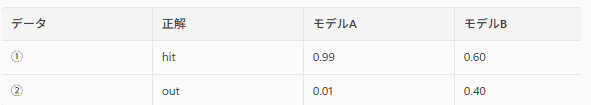<br>
両方とも、hitに高い値、outに低い値を付けているので、順位は完全に同じになる。<br>
⇒この2つは AUC的には同じ性能<br>

しかし、実務で確率データを扱う場合、<br>
**同じクラスに分類された中でも、確信度合いによって自身の強弱の付け方を変えるべき**と考える。<br>
例：明らかにホームランのものには0.95、微妙なものには0.60<br>
⇒キャリブレーション(Temperature Scaling)で**AUCの順位は変えずに、“自信の強弱の付け方”だけを整える**<br>

### 可視化（診断としての役割）
#### Stage1 PR Curve（OOF）
Stage1が「hitを拾う」役割を果たせているかを、PR曲線で確認する。<br>
Recall（横軸）<br>
→ 本当は hit のものを、どれだけ拾えているか<br>
Precision（縦軸）<br>
→ hit と判定したものの中に、どれだけ本当に hit が含まれているか<br>
**ここから何が言えるか：**　<br>
・「hit を厳選すれば、かなり当たりやすい、ただし、hit をたくさん拾おうとすると、out も混ざってくる」という挙動<br>
・Recall をある程度まで上げても、Precision が急激に崩れていない<br>
・「hit を拾うためのモデル」として、挙動が素直<br>
・AP ≈ 0.46 は、ランダム（hit率）より明確に良い<br>
**⇒Stage1 としては十分に機能しており、hit を拾う入口として、無理な挙動をしていない**<br>
<br>
#### Feature Importance（Stage1）
Stage1で「hit/out」を分けるのに、どの特徴が効いているかを確認する。<br>
“特徴量の狙い”が、実際にモデルの判断材料になっているかの検証でもある。<br>
**ここから何が言えるか：**　<br>
**「hit か out か」を分ける段階では、“物理・感覚的に納得できる特徴”が主役になっている**　<br>

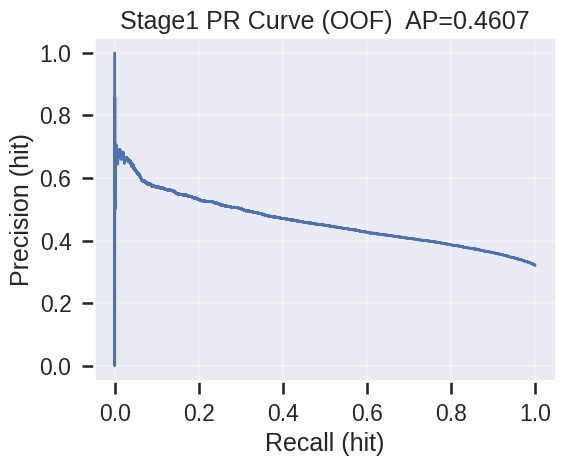

[Stage1 OOF] PR-AUC(AP) = 0.460694


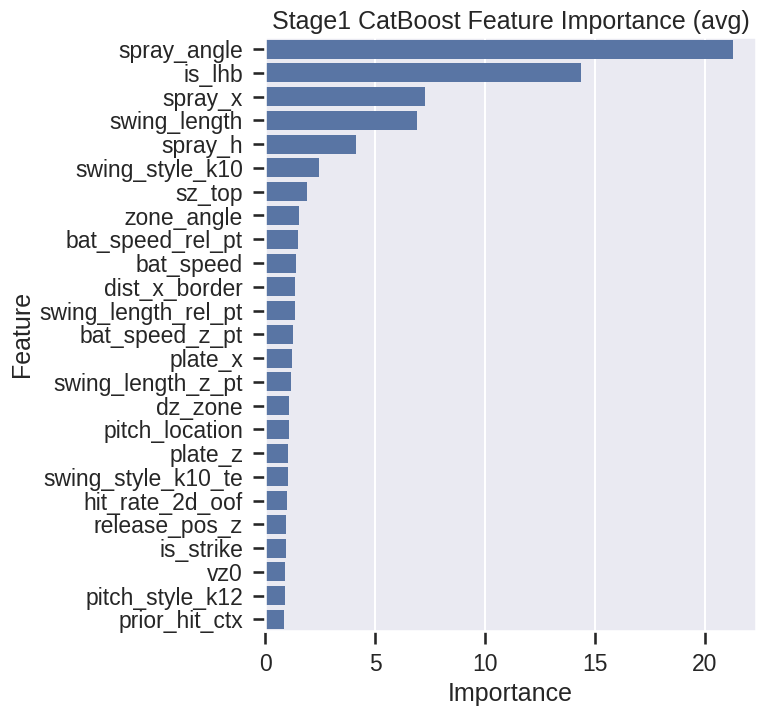

In [144]:
# ===== Cell 8: Visualizations for Improvement (before calibration) =====
# 1) Stage1 PR曲線（しきい値最適化/再学習の足掛かり）
plot_stage1_pr(y_true, res_2stage['stage1']['oof_pred'])

# 2) Feature Importance（代表seedのfold群）
#    ※ res_2stage['stage1']['fold_models'] は Stage1のみ。Stage2は res_2stage['stage2']['fold_models']。
stage1_models = res_2stage['stage1']['fold_models']
feature_names = stage1_models[0].feature_names_

plot_feature_importance(
    models=stage1_models,
    feature_names=feature_names,
    topn=25,
    title="Stage1 CatBoost Feature Importance (avg)"
)

## キャリブレーション（Isotonic + Temperature）
#### なぜ P(out) のみ Isotonic なのか（構造上の理由）
Two-Stageでは P(out) が土台になる。<br>
hit側の全クラス確率は P(hit) を掛けて作られるため、P(out) がズレると全体配分が歪む。<br>
そのため、まず **P(out) を確率として信用できる形へ補正する**のが合理的である。<br>
Isotonic Regressionは「スコアが大きいほど確率も大きい」という順序（単調性）を守りつつ、実測頻度に沿うように柔軟に曲線を学習する。<br>

### Isotonic Calibration（等調較正）
機械学習の分類モデルが出力する確率（予測スコア）を、実際の正解率（事後確率）に近づけるための技術（確率較正）の一つ。<br>
モデルの予測スコアに対して単調非減少（増えることはあっても減ることはない）という制約条件下で、実際の正解データに最も近づくようにマッピングを学習する手法。<br>

**目的**:分類器の出力（0〜1のスコア）が「実際の確率」を反映していない場合に補正する。<br>
**手法**:Isotonic Regression（等調回帰）を使用する。データを分割し、各ブロック内で平均化するようなステップ関数を学習する非パラメトリック手法。<br>
**特徴**:<br>
・**単調性**: スコアが増加すれば、キャリブレーション後の確率も必ず単調に増加する。<br>
・**非パラメトリック**: 特定の関数型（シグモイド関数など）を仮定せず、データに合わせて柔軟に形状を変える。<br>

#### 主な要素とメリット
・**信頼度の高い確率予測**: 信頼度が高いモデルを作成できる（例：予測確率80%のデータが、実際に80%の割合で正解する）<br>
・**不整データへの対応**: データの分布が偏っている、あるいは正解確率が単純な線形関係にない場合でも、柔軟にフィットできる。<br>

#### 注意点
・**過学習 (Overfitting)**: 学習データが少ないと、テストデータに対して精度が低下（過学習）するリスクが高い。<br>
・**適用目安**: 10,000以上のサンプルがある場合に特に有効<br>


#### Reliability Diagram（P(out) の較正前後）
Reliabilityは「確率が信用できるか」を見る図である。<br>
P(out) の較正前後を並べることで、「確率の目盛り」が修正されたかを確認している。<br>

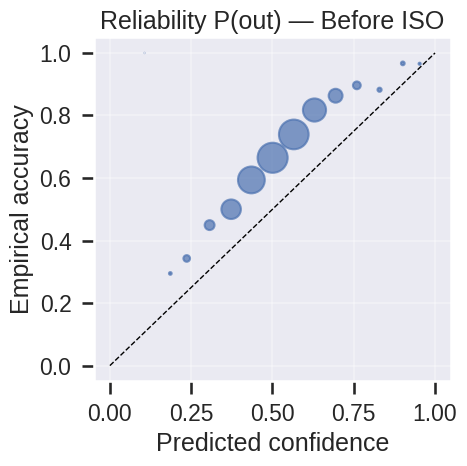

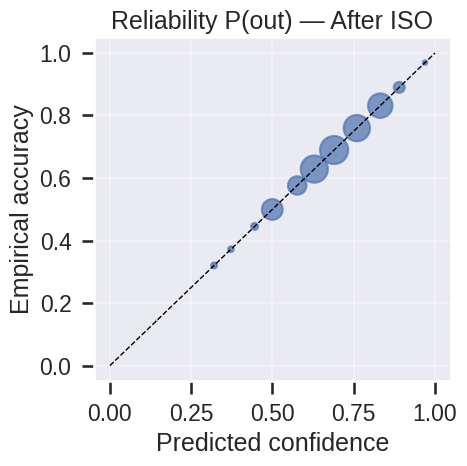

[OOF after ISO] logloss: 0.9353324023286672
HIT-ONLY (after ISO): {'logloss_hit': 2.1351727051997615, 'ece_per_class': {'single': 0.5385015226423376, 'double': 0.10074123733847488, 'triple': 0.048261769008019546, 'home_run': 0.04284587161368635}, 'ece_macro': 0.1825876001506296}


In [145]:
# ===== Cell 9: Calibration Step 1 — Isotonic on P(out) =====
st1_oof = res_2stage['stage1']['oof_pred']  # [:,0]=P(out), [:,1]=P(hit)
p_out_before = st1_oof[:,0]
y_out_bin = (y_true == 0).astype(int)

# 学習（OOFなのでリークなし）
iso = IsotonicRegression(out_of_bounds='clip').fit(p_out_before, y_out_bin)
p_out_after = iso.predict(p_out_before)

# 信頼度曲線（前後）
plot_reliability_binary(y_out_bin, p_out_before, n_bins=15, title="Reliability P(out) — Before ISO")
plot_reliability_binary(y_out_bin, p_out_after,  n_bins=15, title="Reliability P(out) — After ISO")

# OOF 5クラスを再構築
P5_oof_cal = P5_oof.copy()
P5_oof_cal[:,0] = p_out_after
p_hit_after = 1.0 - p_out_after

p_hit_raw = 1.0 - p_out_before
pc_given_hit = np.divide(P5_oof[:,1:], np.clip(p_hit_raw[:,None], 1e-9, 1.0))
P5_oof_cal[:,1:] = p_hit_after[:,None] * pc_given_hit

print("[OOF after ISO] logloss:", log_loss(y_true, P5_oof_cal, labels=[0,1,2,3,4]))
print("HIT-ONLY (after ISO):", metrics_hit_only(y_true, P5_oof_cal))

####  Isotonic（P(out)）適用後(Reliability 図（Before → After）)から分かること
**＜読み方＞** <br>
・破線（y=x）：予測確率＝実際の正解率（理想）<br>
・点：その確率帯に入ったデータの実測正解率<br>
・点が破線より上：モデルが控えめ（実際はもっと当たっている）<br>
・点が破線より下：モデルが過信（実際はそこまで当たっていない）<br>

**Before ISO（補正前）** <br>
点が破線からズレており、「80%と言っているのに、実際は80%ではない」確率帯がある状態である。<br>
⇒順位として当てる能力（AUC）とは別に、自信の目盛りがズレている。<br>
<br>
**After ISO（補正後）** <br>
点がほぼ破線上に並んでいる。<br>
これは、P(out) に関して、「P(out)=0.7 と言った集合は、実際に7割くらい out」という状態に近づいたことを意味する。<br>
確率の“目盛り直し”が効いている。<br>
⇒ **out/hit の土台確率が信用できるようになった。** <br>

#### なぜ hit内は Temperature（べき乗＋再正規化）なのか<br>
hit内4クラスで調整したいのは、「当たりやすさの順番」より **自信の出し方**である。<br>
このNotebookでは、hit内確率に α を掛けて再正規化し、hit-onlyの logloss が最小になる α をOOF上で探索して選ぶ。<br>

#### Temperature Scaling（hit-only）
実際の正解率と一致するように修正するキャリブレーション（Calibration：補正）手法の一つ。<br>

**目的**:モデルが出力する確率（例: 90%の自信でA）が、現実の正解率（実際、90%の確率で正解する）と一致するようにキャリブレーションする。<br>
**今回の手法**:<br>
各サンプルの 4 クラス確率にべき乗 αをかけてから再正規化<br>
・α<1：**鋭く**する → もっと「勝者に寄せる」<br>
・α>1：**平坦**にする → 過信を抑えて「控えめ」に<br>
・α=1：何もしない（元のまま）<br>
⇒この αを OOF の hit-only NLL（= logloss） が最小になるように選ぶ（=確信度の“妥当さ”を最もよくする）<br>

**特徴**:<br>
・**簡単**: 実装が容易。<br>
・**高機能**: 分類器の信頼度を適切に評価できる（ECE: Expected Calibration Errorを低減する）。<br>


In [146]:
# ===== Cell 10: Calibration Step 2 — Temperature on P(c|hit) =====
candidate_alphas = np.arange(1.30, 1.61, 0.05)
best_alpha, best_score = None, None
for a in candidate_alphas:
    P_try = apply_temperature_on_hit(P5_oof_cal, alpha=a)
    m = metrics_hit_only(y_true, P_try)
    if (best_score is None) or (m['logloss_hit'] < best_score):
        best_score, best_alpha = m['logloss_hit'], float(a)

print(f"best alpha (hit-only NLL): {best_alpha}  score={best_score:.6f}")

P5_oof_final = apply_temperature_on_hit(P5_oof_cal, alpha=best_alpha)

ll_before  = log_loss(y_true, P5_oof_cal,   labels=[0,1,2,3,4])
ll_after   = log_loss(y_true, P5_oof_final, labels=[0,1,2,3,4])
ece_before = ece_macro_multiclass(y_true, P5_oof_cal)
ece_after  = ece_macro_multiclass(y_true, P5_oof_final)
br_before  = brier_macro(P5_oof_cal,  y_true)
br_after   = brier_macro(P5_oof_final, y_true)

print(f"5-class logloss: before={ll_before:.6f}  after={ll_after:.6f}")
print(f"5-class ECE    : before={ece_before:.6f}  after={ece_after:.6f}")
print(f"5-class Brier  : before={br_before:.6f}   after={br_after:.6f}")

best alpha (hit-only NLL): 1.6000000000000003  score=2.096335
5-class logloss: before=0.935332  after=0.922889
5-class ECE    : before=0.046798  after=0.045573
5-class Brier  : before=0.090498   after=0.088927


#### Temperature Scaling（hit-only）後の結果：何が完成したか
**① best alpha = 1.6 は何を意味しているか**<br>
ここでは、各クラス確率に べき乗 α をかけて再正規化する処理を行っている。<br>

**α = 1.6 の直感的な意味：**　<br>
・α > 1：確率分布を 平坦にする（過信を抑える）<br>
・α < 1：確率分布を 尖らせる（自信を強める）<br>
⇒今回の最適値が 1.6 ということは、hit 内の分類では、**モデルが全体的に自信を持ちすぎていたので、控えめにしたほうが良い**　<br>
　<br>
**・5-class logloss：土台（out/hit）は正しく、その上の配分（hit 内）が素直になった結果として、5 クラス全体の確率としても矛盾が減った。**　<br>
**・5-class ECE:大きく下がりはしなかったが、確実に改善傾向であり、2段構えの補正が効いていると考えられる。**　<br>
**・5-class Brier:「自信の出しすぎ／出さなさすぎ」が緩和された。**　<br>


#### OOF Confusion Matrix（τ適用後）
混同行列は「どこで間違えているか」を可視化する。<br>
このNotebookでは τ 適用後の最終ラベルで confusion matrix を出し、特に hit内（single/double/triple）で混ざりやすい限界を確認できる。<br>

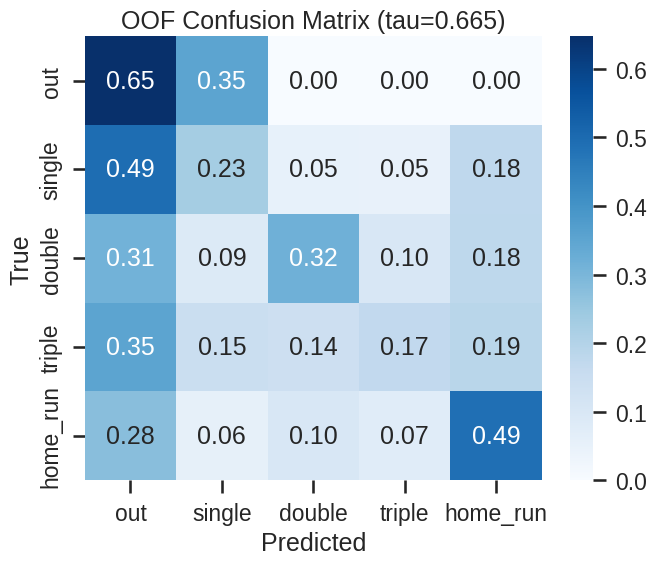

              precision    recall  f1-score   support

         out       0.76      0.65      0.70     33981
      single       0.16      0.23      0.19     10408
      double       0.56      0.32      0.40      3162
      triple       0.05      0.17      0.07       283
    home_run       0.30      0.49      0.37      2166

    accuracy                           0.53     50000
   macro avg       0.37      0.37      0.35     50000
weighted avg       0.60      0.53      0.56     50000



In [147]:
# ===== Cell 11: OOF Confusion Matrix at Best τ (final calibrated P5) =====
best_tau_final = grid_search_tau_on_oof(P5_oof_final, y_true)['tau']
plot_confusion_oof(y_true, P5_oof_final, tau=best_tau_final, normalize=True)


### τ適用後の最終性能から分かること
この結果は、**2‑stage OOF の確率出力に対して τ=0.665 を適用し、最終ラベルを1つに決めた後の性能**である。<br>
つまり「確率モデルの良さ」ではなく、**実運用での言い切り性能**を見ている。<br>
<br>
#### macro AUC は高いのに、混同行列が荒れる理由
今回の 5‑class macro AUC は 0.88 と非常に高い。<br>
これは、各クラスについて「それっぽい順」に並べる能力が高いことを意味する。<br>
<br>
一方、混同行列は<br>
・τ による **out / hit のゲート**<br>
・hit 内での **argmax による1クラス決め打ち**<br>
という**強制的な境界を通した結果**である。<br>
<br>
single が一番それっぽいが、double と僅差<br>
→ AUC 的には正解<br>
→ argmax では double に転ぶ<br>
といった現象が多発する。<br>
これは AUC（順位評価）と混同行列（決断評価）が見ている能力の違いによるものであり、矛盾ではない。<br>

#### 分類レポートから見える構造的な難しさ
**out** <br>
precision は高めだが recall は完璧ではない<br>
→ Stage1 のゲート影響が残る<br>

**single**<br>
precision / recall ともに低い<br>
→ out / double / home_run に挟まれた **最も曖昧なクラス**<br>

**double / triple**<br>
両側（out・home_run）に引っ張られる<br>
→ 境界が連続的で、1点決めが難しい<br>

**home_run**<br>
recall は比較的高いが precision は低い<br>
→ 拾えるが混ざる<br>
<br>
macro F1 が低く、weighted F1 が高いのは、**多数派（out）に引っ張られて見栄えが変わる典型的なパターン**である<br>

#### 混同行列が示している「限界の正体」
混同行列を見ると、<br>
・out ↔ single の相互流入が最大<br>
・single / double / home_run は **僅差で入れ替わる**<br>
・triple はサンプル希少＋特徴弱で全方向に散る<br>
という、**データ構造として自然な混ざり方**が確認できる。<br>

In [149]:
# ===== Cell 12: Apply Calibration to Test & Save Submission =====
P5_test  = res_2stage['test_pred'].copy()
st1_test = res_2stage['stage1']['test_pred']  # [:,0]=P(out)

# 1) Isotonic（OOFで学習済）を test の P(out) に適用
P_out_test_cal = iso.predict(st1_test[:,0])
P_hit_test_cal = 1.0 - P_out_test_cal

# 2) P(c|hit) を復元し掛け直し
P_hit_test_raw = 1.0 - st1_test[:,0]
Pc_given_hit_test = np.divide(P5_test[:,1:], np.clip(P_hit_test_raw[:, None], 1e-9, 1.0))
P5_test_cal = P5_test.copy()
P5_test_cal[:,0]  = P_out_test_cal
P5_test_cal[:,1:] = P_hit_test_cal[:, None] * Pc_given_hit_test


sub_B = pd.DataFrame(P5_test_final, columns=LABELS)
sub_B.insert(0, 'uid', test_id.values)
sub_B.to_csv("submission_iso_only.csv", index=False)
print("Saved: submission_iso_only.csv")

Saved: submission_iso_only.csv


In [150]:
# 非キャリブ（生確率）
sub_A = pd.DataFrame(res_2stage['test_pred'], columns=LABELS)
sub_A.insert(0, 'uid', test_id.values)
sub_A.to_csv("submission_iso_only.csv", index=False)


In [151]:
# 3) Temperature を適用
P5_test_final = apply_temperature_on_hit(P5_test_cal, alpha=best_alpha)

# 保存
sub_df = pd.DataFrame(P5_test_final, columns=LABELS)
sub_df.insert(0, 'uid', test_id.values)
fname = f"submission_after_iso_temperature_a{best_alpha:.2f}.csv"
sub_df.to_csv(fname, index=False)
print("Saved:", fname)

Saved: submission_after_iso_temperature_a1.60.csv


A：非キャリブ（raw） → Private 0.71740<br>
B：Isotonicのみ → Private 0.72026（最良） / Public 0.68998<br>
C：Isotonic＋Temperature → Private 0.72013<br>

In [ ]:
from itertools import product
from sklearn.metrics import average_precision_score

def quick_eval_stage1_with_clusters(train_df, test_df, feature_maker,
                                    y_label='outcome_code',
                                    seeds=(42,52,62), nfolds=5,
                                    pitch_k_list=(8,10,12), swing_k_list=(6,8,10), 
                                    m_list=(80.0,120.0,200.0)):
    # 1) 下準備（ベース特徴）
    tr, te, base_feats, _, _ = _build_features(train_df, test_df, feature_maker, y_label)
    y_full = tr[y_label].astype(int); y_bin = (y_full!=0).astype(int)

    # handedness
    for df in (tr, te):
        if 'is_lhb' in df.columns:
            df['pitch_type_hand'] = (df['pitch_type'].astype(str)+'_'+df['is_lhb'].astype(int).astype(str)).astype('category')
        else:
            df['pitch_type_hand'] = df['pitch_type']

    # 既存の 3D/2D OOF 特徴（固定）
    tr, te, c3 = add_oof_hit_rate_3d(tr, te, y_bin, 
                                     col_x='plate_x', col_h='relative_height', col_pt='pitch_type_hand',
                                     n_bins_x=12, n_bins_h=12, n_splits=nfolds, seed=seeds[0], 
                                     smoothing=90.0, out_col='hit_rate_3d_oof')
    tr, te, c2 = add_oof_hit_rate_2d_quantile(tr, te, y_bin,
                                              col_x='plate_x', col_z='relative_height',
                                              n_bins_x=16, n_bins_z=14, n_splits=nfolds, seed=seeds[0], 
                                              smoothing=120.0, out_col='hit_rate_2d_oof')

    results = []
    for pk, sk, m in product(pitch_k_list, swing_k_list, m_list):
        tr1, te1 = tr.copy(), te.copy()

        # クラスタ作成
        tr1, te1, pitch_cols = add_kmeans_cluster_labels(tr1, te1, PITCH_COLS, [pk], prefix='pitch_style', random_state=42)
        tr1, te1, swing_cols = add_kmeans_cluster_labels(tr1, te1, SWING_COLS, [sk],  prefix='swing_style', random_state=42)

        # クラスタごと OOF-TE
        te_cols=[]
        for c in pitch_cols + swing_cols:
            tr1, te1, _ = add_oof_rate_by_cat(tr1, te1, y_bin, cat_col=c, out_col=f"{c}_te", m=m, n_splits=nfolds, seed=seeds[0])
            te_cols.append(f"{c}_te")

        # 文脈TE（固定）
        for df in (tr1, te1):
            if {'is_lhb','is_lhp'}.issubset(df.columns):
                df['platoon_adv'] = (df['is_lhb'].astype('int8') ^ df['is_lhp'].astype('int8'))
        tr1, te1, ctx = add_oof_te_binary(tr1, te1, y_bin,
                                          keys=['balls','strikes','outs_when_up','platoon_adv','pitch_type_hand'],
                                          out_col='prior_hit_ctx', m=120.0, n_splits=nfolds, seed=seeds[0])

        # Stage1 features
        feats = base_feats + [c3,c2,ctx] + pitch_cols + swing_cols + te_cols
        cat_cols = tr1[feats].select_dtypes(include=['category','object']).columns.tolist()
        cat_idx   = [feats.index(c) for c in cat_cols] if cat_cols else None

        # Stage1だけ学習してPR-AUCを評価
        st1 = _seed_bagging_catboost_binary(tr1, te1, feats, cat_idx, y_bin, seeds=seeds, nfolds=nfolds, params=None)
        prauc = average_precision_score(y_bin, st1['oof_pred'][:,1])
        results.append({'pitch_k':pk, 'swing_k':sk, 'm':m, 'prauc':float(prauc)})
        print(f"[pitch_k={pk}, swing_k={sk}, m={m}]  PR-AUC={prauc:.6f}")

    results = pd.DataFrame(results).sort_values('prauc', ascending=False)
    print("\nTop-5:")
    print(results.head(5))
    return results

現状<br>
Stage1（P(out)）の較正は効いている（hit‑only でも NLL/ECE が小幅改善）。<br>
ただし hit 内 4 クラスの “確信度（calibration）の歪み” は大半が残存。<br>
特に single の ECE ≈ 0.53 が突出しており、確信の置き方が著しくズレている。<br>
triple は Brier が極小で「基本 0 を出す」性格上、ECE の微動は解釈に注意が必要。<br>
まとめ：識別（どれを選ぶか）は二段階化＋τで改善している一方、確信度（確率の妥当性）は hit 側、とくに single が未整合のまま。<br>
後段の 温度スケーリング（α > 1 の flatten） を hit‑only に適用して、single の過信（または過小）の是正を図る余地が大きいです。<br>